In [1]:
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 

In [2]:
df=pd.read_csv("../data/raw/credit_risk_dataset.csv")

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.shape

(32581, 12)

In [5]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [7]:
df.duplicated().sum()

np.int64(165)

In [8]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [9]:
# Target columsn is ['loan_status]
df['loan_status'].unique()

array([1, 0])

In [10]:
# Now we will check the class imbalance /Traget balance  
# Below is the google defination 
'''
Target balance refers to an equal or desired distribution of classes in a dataset, 
whereas class imbalance describes a state of unequal representation where one class heavily dominates the other

Target BalanceDefinition: A state where the target or dependent variable has roughly equal numbers of samples for each category 
(e.g., a 50/50 split in binary classification).Goal: To provide a model with balanced learning signals so it does not favor any single category.
Creation: Can be achieved naturally or artificially via resampling methods like SMOTE

Class ImbalanceDefinition: A data distribution problem where one category (the majority class) significantly outnumbers the other category 
(the minority class).Problem: Causes machine learning models to become biased, 
yielding misleadingly high accuracy while failing to predict the minority class.Examples: Fraud detection, rare disease screening, 
and equipment failure prediction
'''

'\nTarget balance refers to an equal or desired distribution of classes in a dataset, \nwhereas class imbalance describes a state of unequal representation where one class heavily dominates the other\n\nTarget BalanceDefinition: A state where the target or dependent variable has roughly equal numbers of samples for each category \n(e.g., a 50/50 split in binary classification).Goal: To provide a model with balanced learning signals so it does not favor any single category.\nCreation: Can be achieved naturally or artificially via resampling methods like SMOTE\n\nClass ImbalanceDefinition: A data distribution problem where one category (the majority class) significantly outnumbers the other category \n(the minority class).Problem: Causes machine learning models to become biased, \nyielding misleadingly high accuracy while failing to predict the minority class.Examples: Fraud detection, rare disease screening, \nand equipment failure prediction\n'

In [11]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

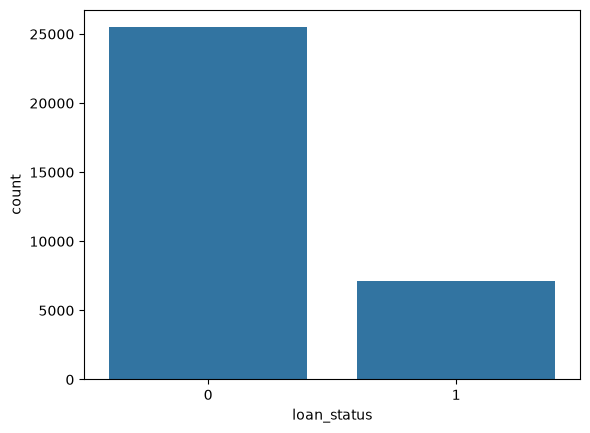

In [12]:
sns.countplot(data=df,x='loan_status')

In [13]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [14]:
# Outliers
'''To check the outliers we will use boxplot but to use tht we nned numerical columns we will extract tht'''

'To check the outliers we will use boxplot but to use tht we nned numerical columns we will extract tht'

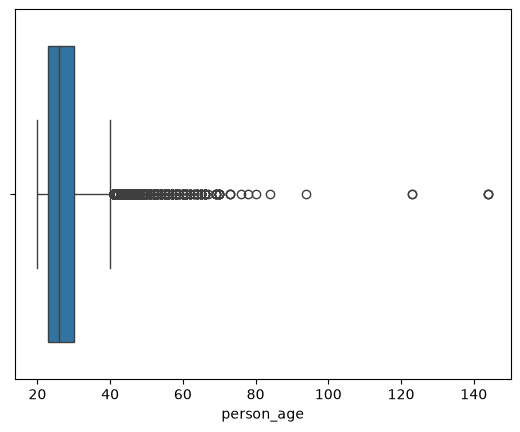

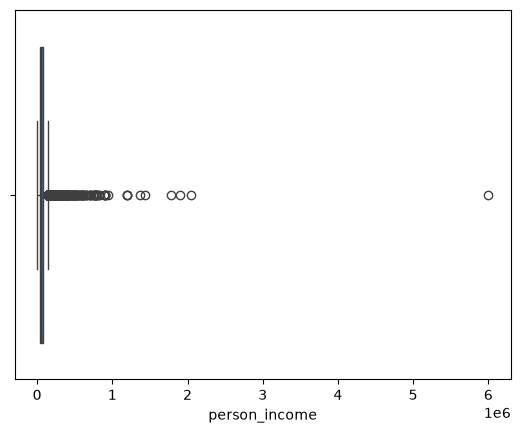

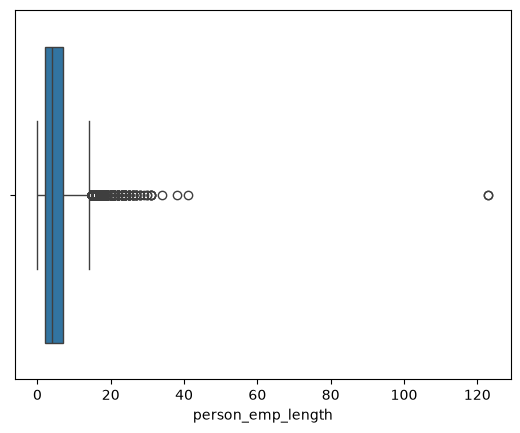

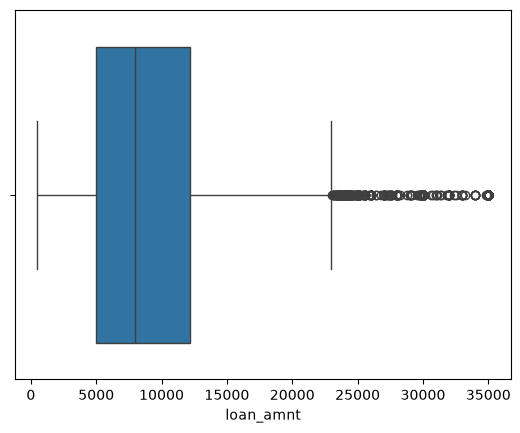

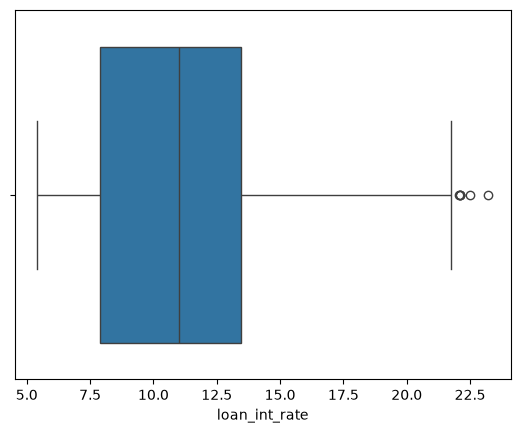

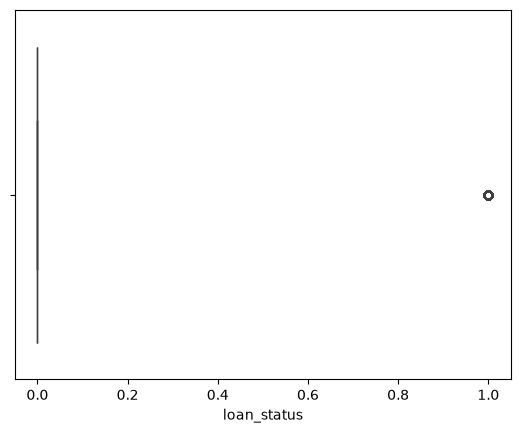

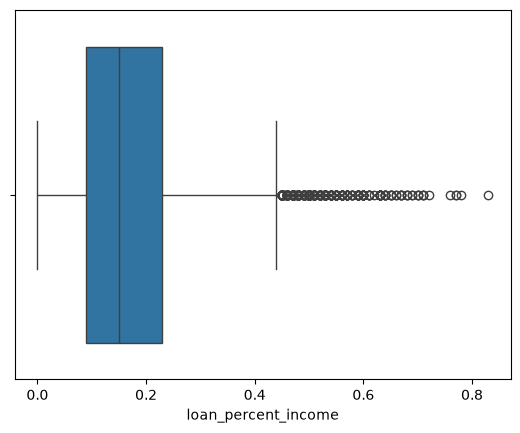

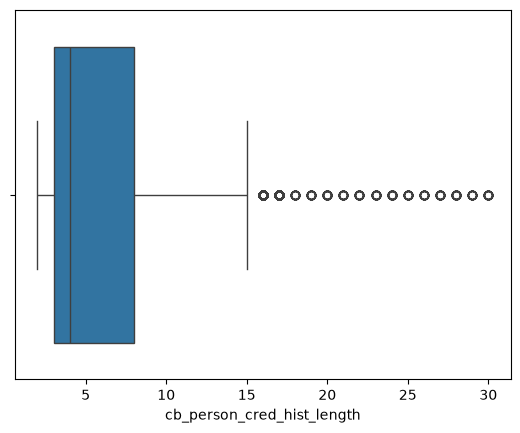

In [15]:
num_cols=df.select_dtypes(include=np.number)
num_cols.columns

for num in num_cols:
    sns.boxplot(x=df[num])

    plt.show()


In [16]:
(df['person_age']>100).sum()

np.int64(5)

In [17]:
# Now we will check the correlation 

<Axes: >

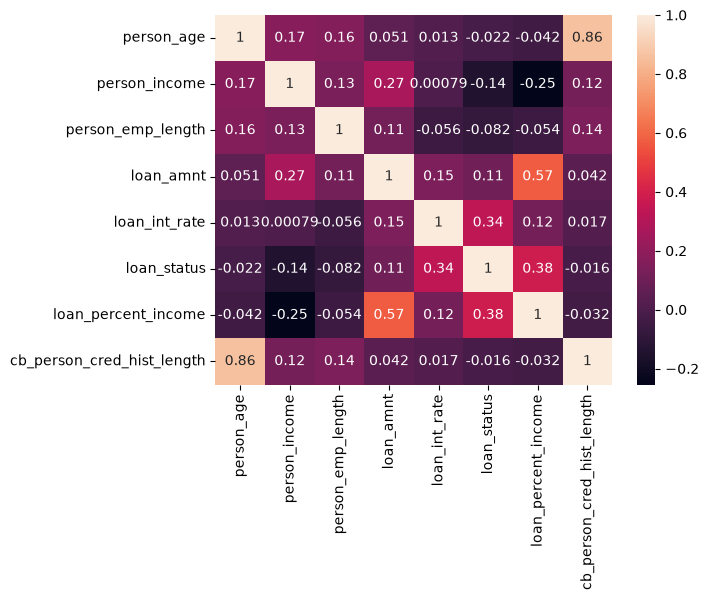

In [18]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [19]:
df_copy=df.copy()

 DATA CLEANING

In [20]:
df_copy = df.copy()

print(f"Original Rows: {df_copy.shape[0]}")

#Remove Duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

#Remove ages below 18 or below 100
df_copy = df_copy[df_copy['person_age'] >=18]
df_copy = df_copy[df_copy['person_age'] <=100]

#Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

#Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]

#check if the interest rate looks realistic.
print("Loan intreset rate range from (min: 5.42 and max: 23.22)")

Original Rows: 32581
Rows after removing duplicates : 32416
Loan intreset rate range from (min: 5.42 and max: 23.22)


In [21]:
df_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31522.000000,3.152200e+04,31522.000000,31522.000000,28495.000000,31522.000000,31522.000000,31522.000000
mean,27.742529,6.650168e+04,4.782850,9663.771334,11.045220,0.215944,0.169658,5.816097
std,6.218713,5.275216e+04,4.037343,6334.787700,3.230786,0.411482,0.106296,4.063622
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.943800e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Train Test Split 

In [22]:
x=df_copy.drop('loan_status',axis=1)
y=df_copy['loan_status']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42,stratify=y)

'''
stratify=y is used in train_test_split() to make sure the class/target distribution stays approximately the same in both training and testing data.
'''

# Extra note what normalize does i got this question so thought to share here 
# normalize=True = give me percentage/proportion instead of raw count

'\nstratify=y is used in train_test_split() to make sure the class/target distribution stays approximately the same in both training and testing data.\n'

In [24]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(21119, 11)
(10403, 11)
(21119,)
(10403,)


In [25]:
numerical_cols=x.select_dtypes(include=np.number).columns
categorical_cols=x.select_dtypes(include=['category','object']).columns

C:\Users\arpan\AppData\Local\Temp\ipykernel_25528\1699549630.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=x.select_dtypes(include=['category','object']).columns


In [26]:
print("numerical_cols=",numerical_cols)
print("categorical_cols=",categorical_cols)

numerical_cols= Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='str')
categorical_cols= Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')


HANDLE CLASS IMBALANCE

In [27]:
print(y.value_counts(normalize=True))

loan_status
0    0.784056
1    0.215944
Name: proportion, dtype: float64


In [28]:
# To handle class imbalance, there are several techniques. Some commonly used techniques are:
# 1. Class Weights

# Give more importance to the minority class during model training, without changing the dataset.

# 2. Oversampling

# Increase the number of minority-class samples.

# Random Oversampling: duplicates existing minority samples.
# SMOTE: creates synthetic minority samples.
# 3. Undersampling

# Reduce the number of majority-class samples to make the classes more balanced.

# 4. Threshold Adjustment

# Change the classification probability threshold instead of always using the default 0.5, which can help improve recall for the minority class.

# 5. Combination Methods

# Combine techniques such as SMOTE + undersampling to handle severe class imbalance.

# 6. Use Appropriate Evaluation Metrics

# Accuracy alone can be misleading with imbalanced data, so use metrics such as Precision, Recall, F1-score, ROC-AUC, PR-AUC, and Confusion Matrix.

# Important: When using oversampling/SMOTE/undersampling, apply it only to the training data, not before the train-test split, to avoid data leakage.

In [29]:
# WE WILL USE THE WEIGHTS METHOD TO HANDLE CLASS IMBALANCE
#0 -> no loan (most)
#1 -> yes loan

# NOTE - XG BOOST DOES NOT HAEV INBUILT WEIGHTS THING BUT LOGISTIC REGRESSION HAD 

In [30]:
neg,pos=np.bincount(y_train)
scale_weigths=neg/pos
scale_weigths

np.float64(3.630344222758167)

DATA PREPROCESSING AND PIPELINE

1. Logistic Regression

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [34]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Missing"
    )),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_lr = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])


# we can also do this directyly 
# preprocessor_lr = ColumnTransformer(
#     transformers=[
#         #Pipeline - for numerical cols
#         ('num', Pipeline([
#             ('imputer', SimpleImputer(strategy='median')),
#             ('scaler', StandardScaler())
#         ]), numeric_cols),

#         #Pipeline - for Categorical cols.
#         ('cat', Pipeline([
#             ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
#             ('onehot', OneHotEncoder(handle_unknown='ignore'))
#         ]), categorical_cols)
#     ])


2.XGBOOST


In [ ]:
# XGBoost: Impute numeric only (No Scaling),
# impute + One-Hot Encoding for categorical

preprocessor_xg = ColumnTransformer(
    transformers=[
        
        # Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numerical_cols),

        # Pipeline - for categorical cols
        ('cat', Pipeline([
            ('imputer', SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)


# Why no StandardScaler?

# XGBoost is a tree-based model.

# Tree models split based on conditions such as:

# income < 50000
# income < 75000
# income < 100000

# So the actual scale of the feature isn't important.

# For example:

# income: 20,000 → 100,000

# doesn't need to become:

# -1.2 → 1.5 